#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### Students Performance in Exams Dataset

The **Students Performance in Exams** dataset contains information about students and their exam scores.
It includes students' **gender, parental education, lunch type, and test preparation course**.
The dataset also contains their scores in **math, reading, and writing**.
It can be used to study **what factors may affect students' academic performance**.

| Feature Name                  | Meaning                                            | Easy Explanation                                                                                                               |
| ----------------------------- | -------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| `gender`                      | Gender of the student                              | Tells whether the student is **male or female**.                                                                               |
| `race/ethnicity`              | Race or ethnicity group                            | Shows which **group/category** the student belongs to, such as Group A, B, C, D, or E.                                         |
| `parental level of education` | Highest education level of the student's parents   | Shows how much **education the student's parents have completed**, such as high school, bachelor's degree, or master's degree. |
| `lunch`                       | Type of lunch received by the student              | Shows whether the student receives **standard lunch** or **free/reduced lunch**.                                               |
| `test preparation course`     | Whether the student completed a preparation course | Shows whether the student **completed a test preparation course** or did not take one.                                         |
| `math score`                  | Student's mathematics exam score                   | Shows how many **marks the student obtained in the math exam**.                                                                |
| `reading score`               | Student's reading exam score                       | Shows how many **marks the student obtained in the reading exam**.                                                             |
| `writing score`               | Student's writing exam score                       | Shows how many **marks the student obtained in the writing exam**.                                                             |


### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

#### Import the CSV Data as Pandas DataFrame

In [92]:
df = pd.read_csv('data/StudentsPerformance.csv')

#### Show Top 5 Records

In [93]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [94]:
df.shape

(1000, 8)

### 2.2 Dataset Information.

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing Values

In [95]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### Insights
No Null Values in the dataset

### 3.2 Check Duplicates

In [96]:
# df[df.duplicated()]    
df.duplicated().sum()

0

### insights
No duplicate Values in the dataset


### 3.3 Checking Data Type

In [97]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

### 3.4 Checking Unique Values in each Column.

In [98]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 Statistical Summary of the Dataset.

In [99]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Insights
- All mean values are very close to each other.
- All std values are very close to each other range 14.6 to 15.1.
- Minimum score for maths,reading,writing are 0,10,17.

In [100]:
catagorical_columns = [col for col in df.columns if df[col].dtypes == 'O']
print(len(catagorical_columns))

5


### 3.6 mCheck various categories present in the different categorical column

In [101]:
print("Categories in 'Gender' Column:",end=' ')
print(df['gender'].unique())
print('\n')
print("Categories in 'race/ethnicity' Column:",end=' ')
print(df['race/ethnicity'].unique())
print('\n')
print("Categories in'parental level of education' Column:",end=" " )
print(df['parental level of education'].unique())
print('\n')
print("Categories in 'lunch' Column:     ",end=" " )
print(df['lunch'].unique())
print('\n')
print("Categories in 'test preparation course' Column:     ",end=" " )
print(df['test preparation course'].unique())

Categories in 'Gender' Column: ['female' 'male']


Categories in 'race/ethnicity' Column: ['group B' 'group C' 'group A' 'group D' 'group E']


Categories in'parental level of education' Column: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


Categories in 'lunch' Column:      ['standard' 'free/reduced']


Categories in 'test preparation course' Column:      ['none' 'completed']


### 3.7 Check the Number of Numerical and Categorical Features.

In [102]:
categorical = [col for col in df.columns if df[col].dtypes == 'O']
numerical = [col for col in df.columns if df[col].dtypes != 'O']

print(f"We have {len(categorical)} Categorical Columns in this dataframe \n {categorical}")
print("\n")
print(f"We have {len(numerical)} Numerical Columns in this dataframe \n {numerical}")

We have 5 Categorical Columns in this dataframe 
 ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


We have 3 Numerical Columns in this dataframe 
 ['math score', 'reading score', 'writing score']


In [103]:
df = df.rename(columns={'parental level of education':'parental_level_of_education','test preparation course':'test_preparation_course'})

### 3.8 Adding columns for "Total Score" and "Average"

In [104]:
df['Total Score'] = df['math score'] + df['reading score'] + df['writing score']
df['Average'] = df['Total Score']/3

In [105]:
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math score,reading score,writing score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [106]:
reading_full =df[df['reading score'] == 100]['Average'].count()
writing_full =df[df['writing score'] == 100]['Average'].count()
math_full =df[df['math score'] == 100]['Average'].count()

print('Number of Students with full marks in Maths',math_full)
print('Number of Students with full marks in Writing',writing_full)
print('Number of Students with full marks in Reading',reading_full)

Number of Students with full marks in Maths 7
Number of Students with full marks in Writing 14
Number of Students with full marks in Reading 17


In [107]:
reading_less =df[df['reading score'] < 20]['Average'].count()
writing_less =df[df['writing score'] < 20]['Average'].count()
math_less =df[df['math score'] < 20]['Average'].count()

print('Number of Students with less than 20 marks in Maths',math_less)
print('Number of Students with less than 20 marks in Writing',writing_less)
print('Number of Students with less than 20 marks in  Reading',reading_less)

Number of Students with less than 20 marks in Maths 4
Number of Students with less than 20 marks in Writing 3
Number of Students with less than 20 marks in  Reading 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

### 4.1.1 Histogram & KDE

In [108]:
df.head(2)

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math score,reading score,writing score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


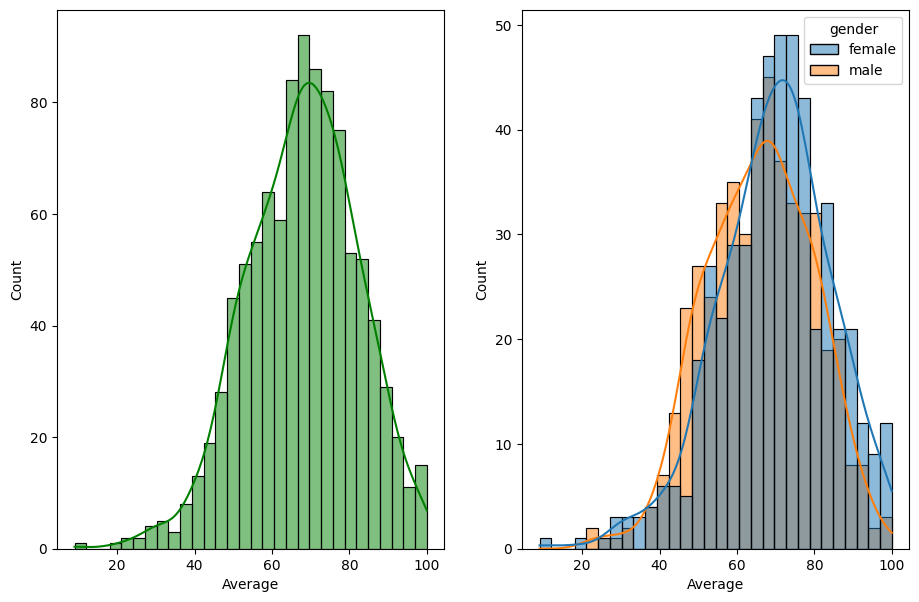

In [109]:
fig,axis = plt.subplots(1,2,figsize=(11,7))

sns.histplot(data=df,x='Average',bins=30,color='g',kde=True,ax=axis[0])

sns.histplot(data=df,x='Average',bins=30,color='g',kde=True,hue='gender',ax=axis[1])
plt.show()

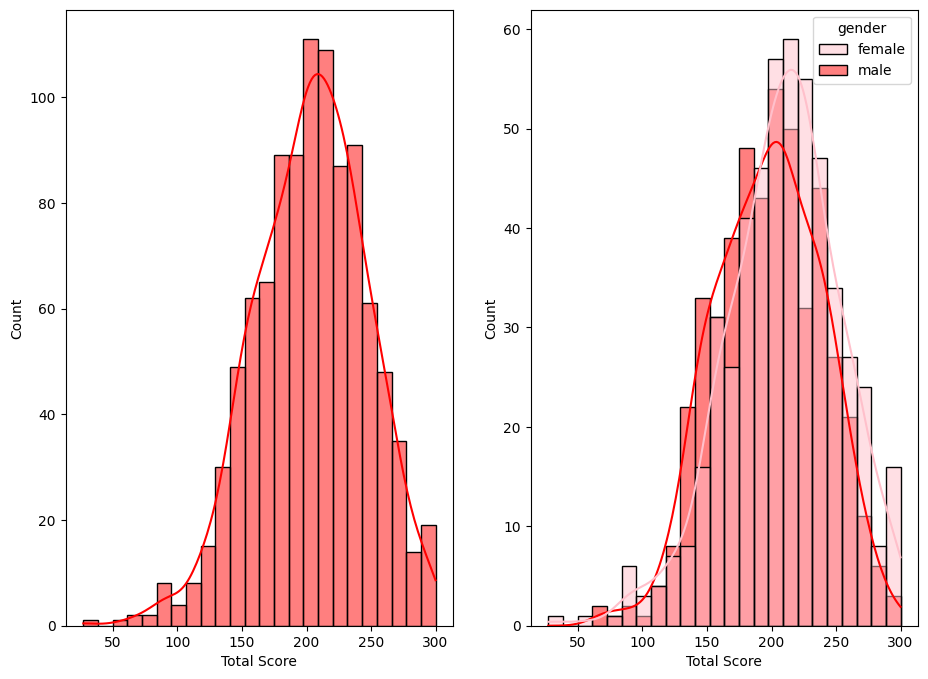

In [110]:
fig,axs = plt.subplots(1,2,figsize=(11,8))

sns.histplot(data=df,x='Total Score',color='r',ax=axs[0],kde=True)

sns.histplot(data=df,x='Total Score',color='r',ax=axs[1],kde=True,hue='gender',
             palette={'male':'red','female':'pink'})

plt.show()

### Insights
Females performs better than Males.

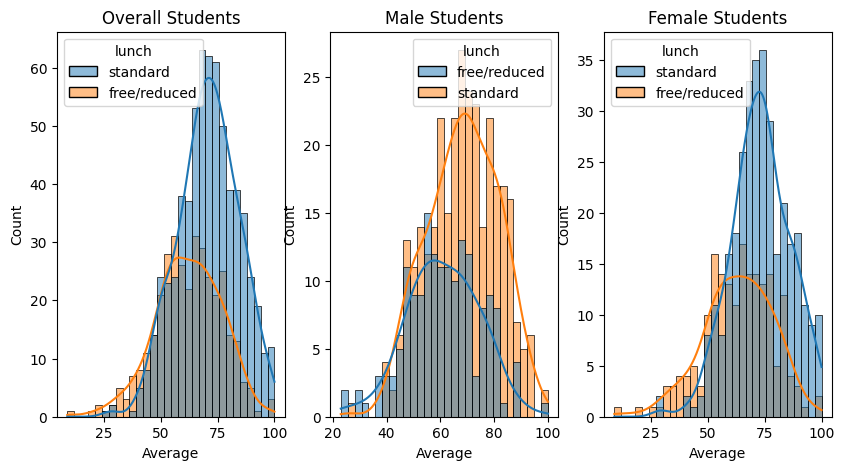

In [111]:
fig,axs=plt.subplots(1,3,figsize=(10,5))

sns.histplot(data=df,x='Average',bins=30,kde=True,color='g',ax=axs[0],hue='lunch')
axs[0].set_title('Overall Students')
sns.histplot(data=df[df['gender']=='male'],x='Average',bins=30,kde=True,color='g',ax=axs[1],hue='lunch')
axs[1].set_title('Male Students')
sns.histplot(data=df[df['gender']=='female'],x='Average',bins=30,kde=True,color='g',ax=axs[2],hue='lunch')
axs[2].set_title('Female Students')

plt.show()

### Insights
- Standard Lunch help Perform better in Exams for both Males and Females.

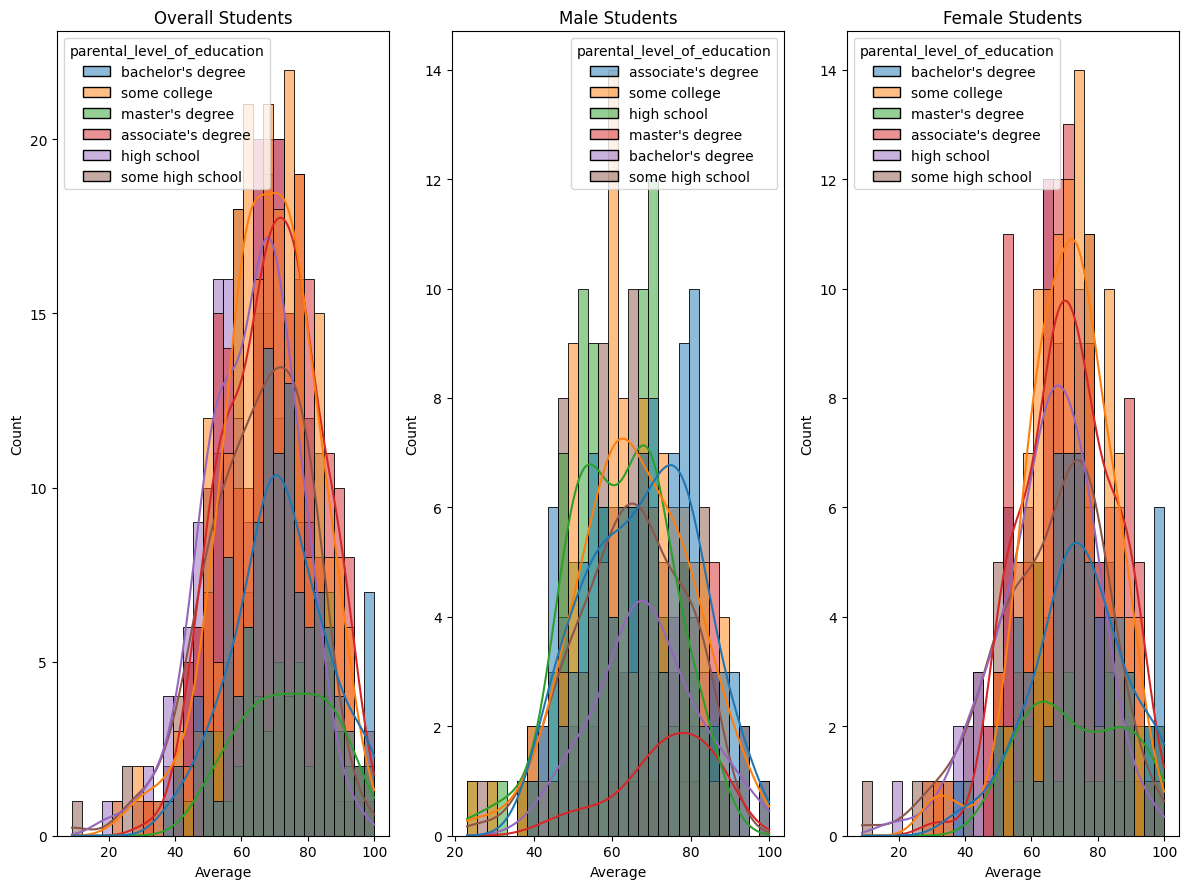

In [112]:
fig,axs=plt.subplots(1,3,figsize=(12,9))

sns.histplot(data=df,x='Average',bins=30,kde=True,color='g',ax=axs[0],hue='parental_level_of_education')
axs[0].set_title('Overall Students')
sns.histplot(data=df[df['gender']=='male'],x='Average',bins=30,kde=True,color='g',ax=axs[1],hue='parental_level_of_education')
axs[1].set_title('Male Students')
sns.histplot(data=df[df['gender']=='female'],x='Average',bins=30,kde=True,color='g',ax=axs[2],hue='parental_level_of_education')
axs[2].set_title('Female Students')

plt.tight_layout()
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

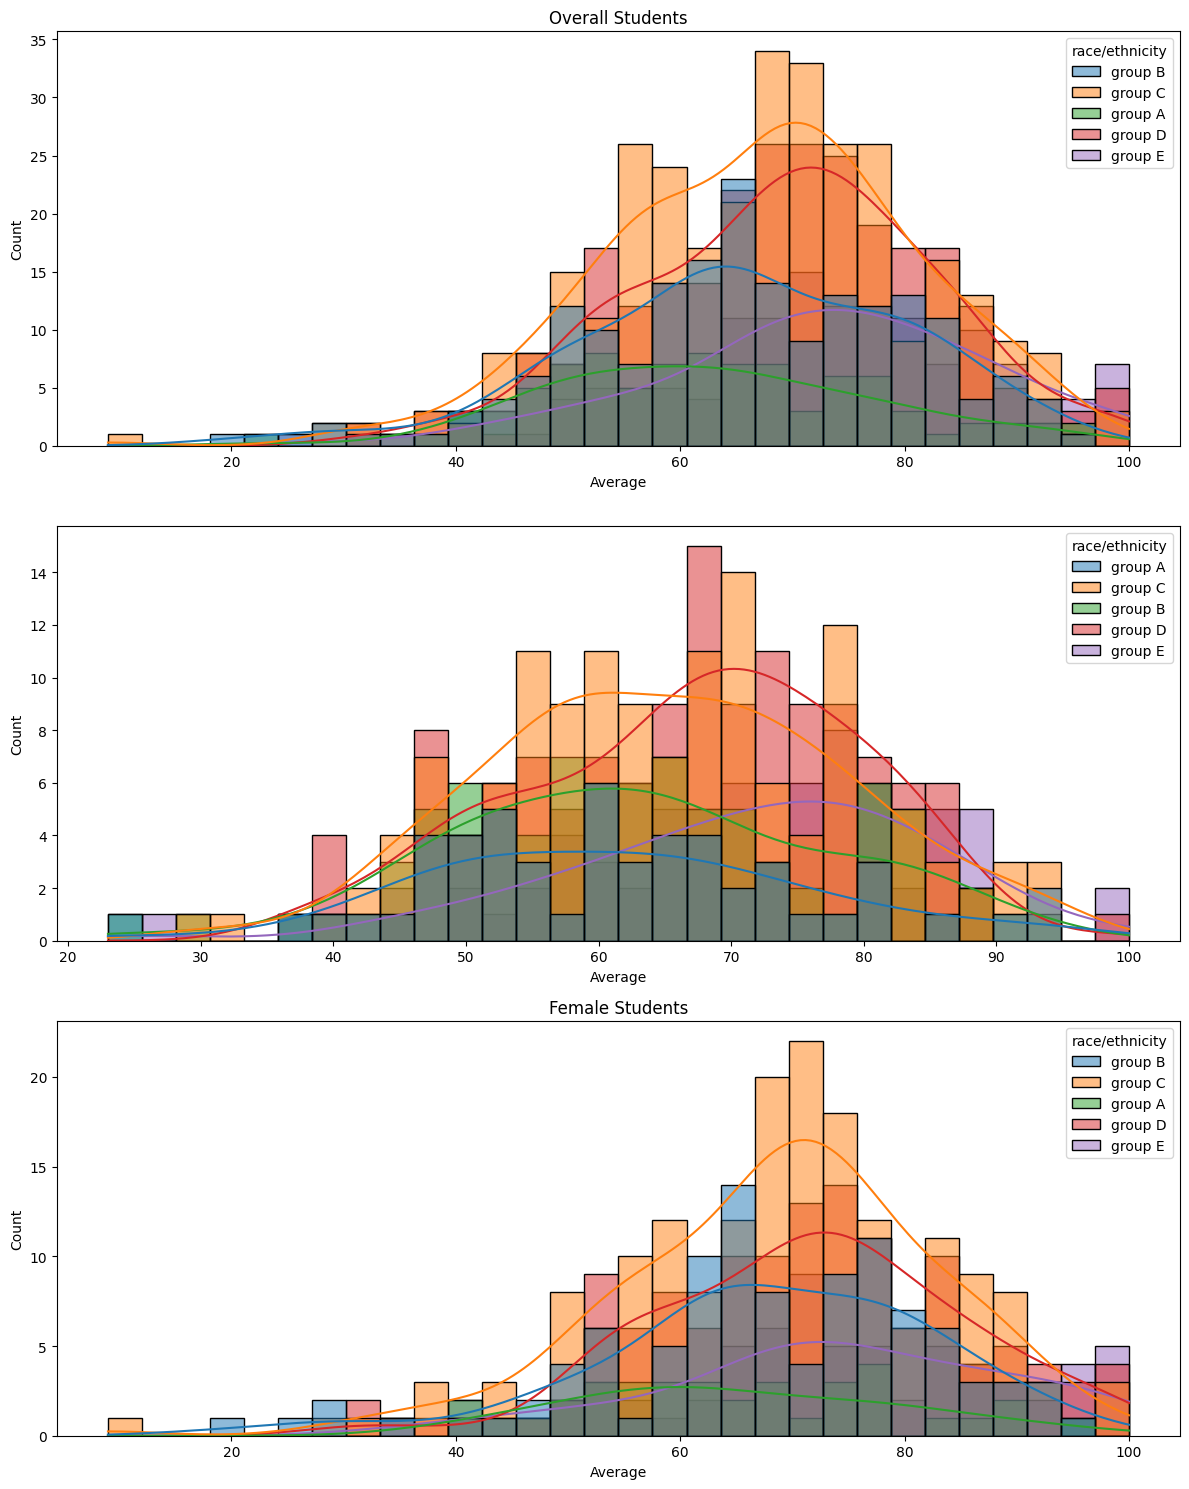

In [113]:
fig,axs=plt.subplots(3,1,figsize=(12,15))

sns.histplot(data=df,x='Average',bins=30,kde=True,color='g',ax=axs[0],hue='race/ethnicity')
axs[0].set_title('Overall Students')
sns.histplot(data=df[df['gender']=='male'],x='Average',bins=30,kde=True,color='g',ax=axs[1],hue='race/ethnicity')
sns.histplot(data=df[df['gender']=='female'],x='Average',bins=30,kde=True,color='g',ax=axs[2],hue='race/ethnicity')
axs[2].set_title('Female Students')

plt.tight_layout()
plt.show()

### Insight
- Students of Group A and B performs poorly in Exams Whether they are Males or Female

In [114]:
df.head(2)

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math score,reading score,writing score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


#### 4.2 Maximumum score of students in all three subjects

Text(0.5, 1.0, 'Writings Score')

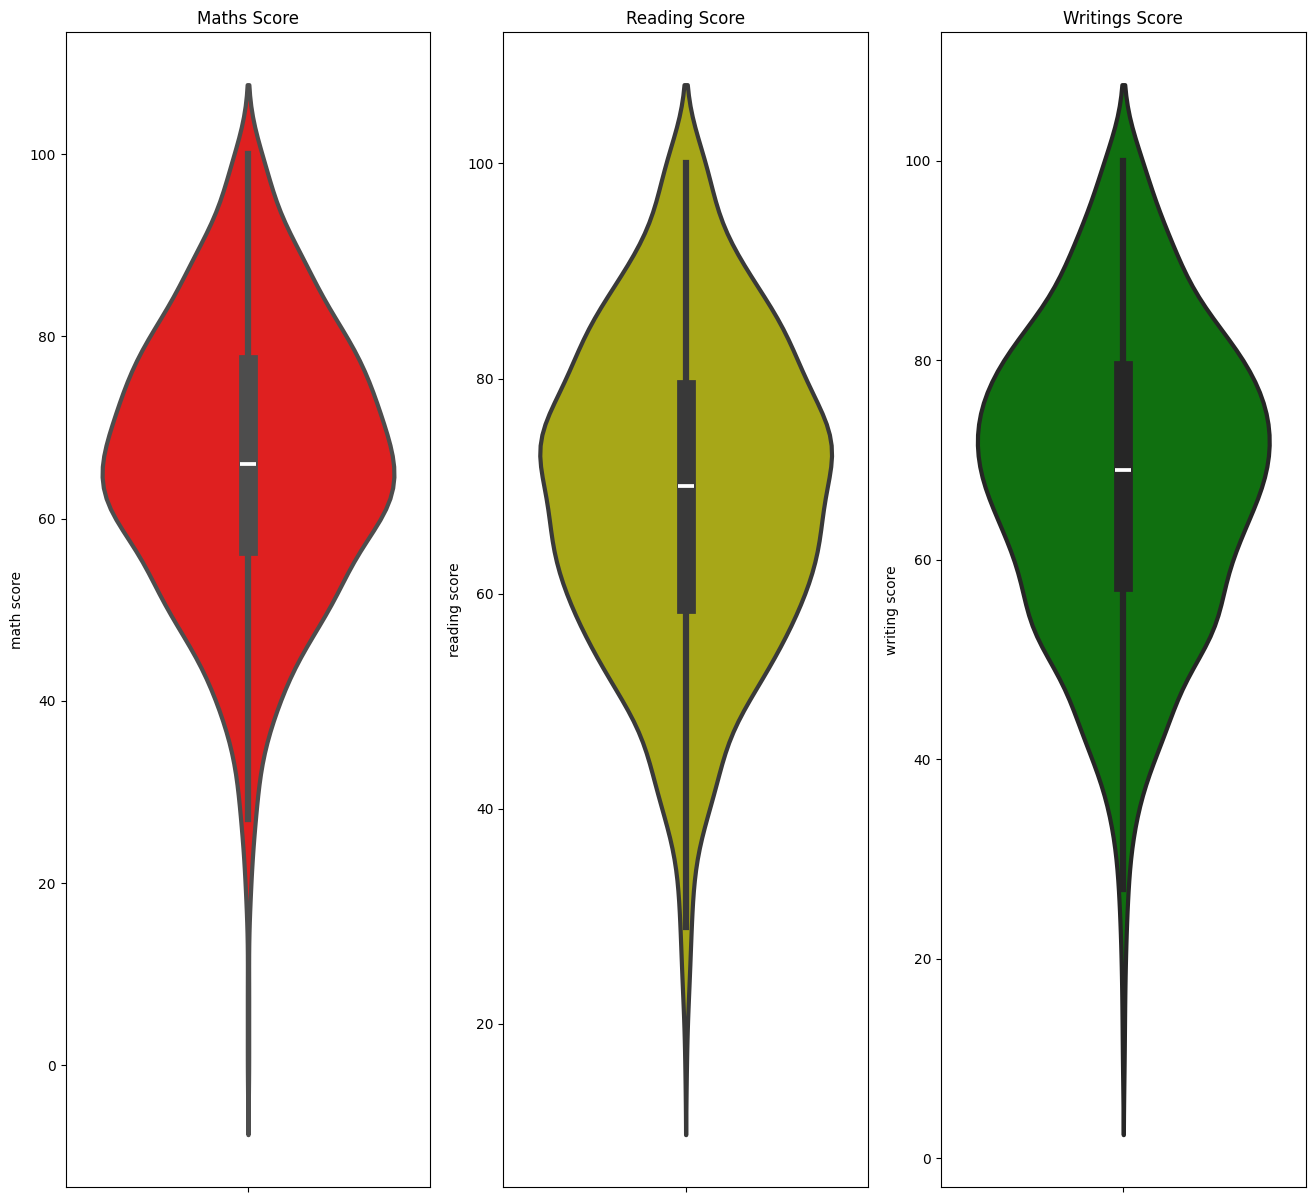

In [115]:
fig,axs=plt.subplots(1,3,figsize=(16,15))

sns.violinplot(data=df,y='math score',ax=axs[0],color='r',linewidth=3)
axs[0].set_title("Maths Score")

sns.violinplot(data=df,y='reading score',ax=axs[1],color='y',linewidth=3)
axs[1].set_title("Reading Score")

sns.violinplot(data=df,y='writing score',ax=axs[2],color='g',linewidth=3)
axs[2].set_title("Writings Score")

#### 4.3 Multivariate analysis using pieplot

In [116]:
print(catagorical_columns)

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [117]:
df.head(2)

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math score,reading score,writing score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


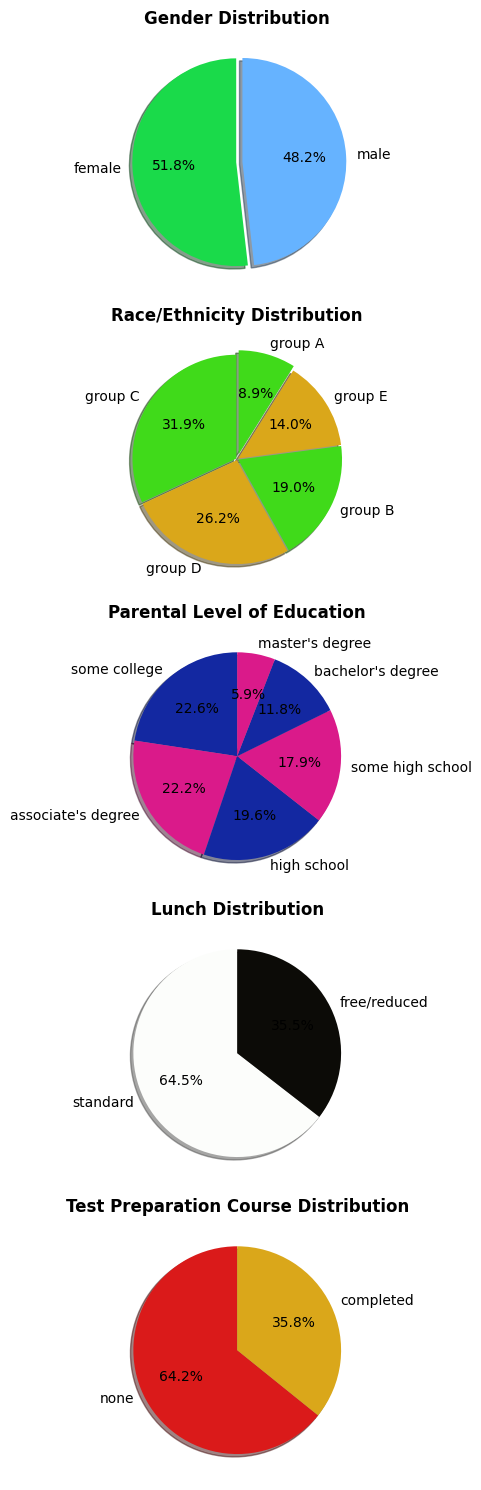

In [118]:
fig,axs=plt.subplots(5,1,figsize=(30,15))

size = df['gender'].value_counts()
axs[0].pie(size,labels=size.index,autopct='%1.1f%%',startangle=90,colors=["#1ada4a",'#66b3ff'],explode=[0.01,0.05],shadow=True)
axs[0].set_title("Gender Distribution",fontweight='bold')
size1 = df['race/ethnicity'].value_counts()
axs[1].pie(size1,labels=size1.index,autopct='%1.1f%%',startangle=90,colors=["#40da1a","#daa71a"],explode=[0.01,0.01,0.01,0.01,0.05],shadow=True)
axs[1].set_title("Race/Ethnicity Distribution",fontweight='bold')
size2 = df['parental_level_of_education'].value_counts()
axs[2].pie(size2,labels=size2.index,autopct='%1.1f%%',startangle=90,colors=["#1328a1","#da1a8a"],shadow=True)
axs[2].set_title("Parental Level of Education",fontweight='bold')
size3 = df['lunch'].value_counts()
axs[3].pie(size3,labels=size3.index,autopct='%1.1f%%',startangle=90,colors=["#fcfdfb","#0c0b07"],shadow=True)
axs[3].set_title("Lunch Distribution",fontweight='bold')
size4 = df['test_preparation_course'].value_counts()
axs[4].pie(size4,labels=size4.index,autopct='%1.1f%%',startangle=90,colors=["#da1a1a","#daa71a"],shadow=True)
axs[4].set_title("Test Preparation Course Distribution",fontweight='bold')

plt.tight_layout()
plt.show()

### Insights
- Number of Male and Female Students are almost same.
- Group C has the highest number of Students.
- Number of students whose parental education is **Some College** is greater followed closely by *associate's degree*.
- Number of Students with standard Lunch are greater.
- Number of Students who did not enrolled in any test preperation course are greater.

# **************
#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### How is distribution of Gender ?

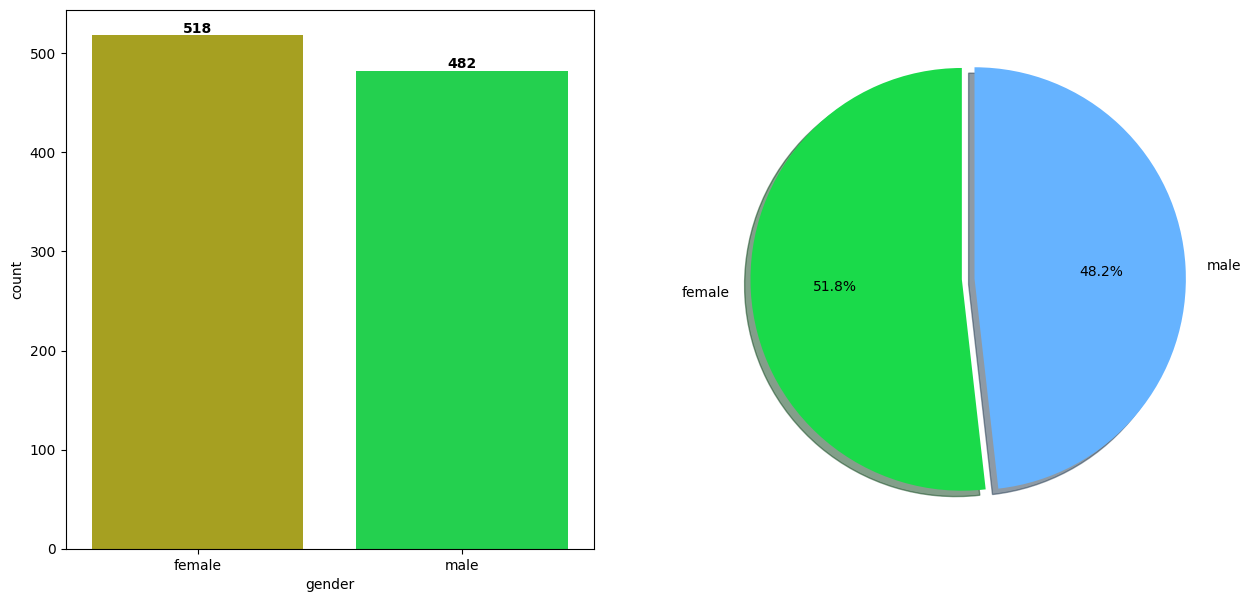

In [119]:
fig,axs = plt.subplots(1,2,figsize=(15,7))

sns.countplot(data=df,x='gender',ax=axs[0],saturation=0.9,palette=['#ada71a','#1ada4a'])
for container in axs[0].containers:
    axs[0].bar_label(container,weight='bold')

plt.pie(df['gender'].value_counts(),labels=df['gender'].value_counts().index,autopct='%1.1f%%',startangle=90,colors=["#1ada4a",'#66b3ff'],explode=[0.01,0.05],shadow=True)
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

In [120]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,Total Score,Average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


In [121]:
gender_group['Average'][0]

69.56949806949807

<BarContainer object of 2 artists>

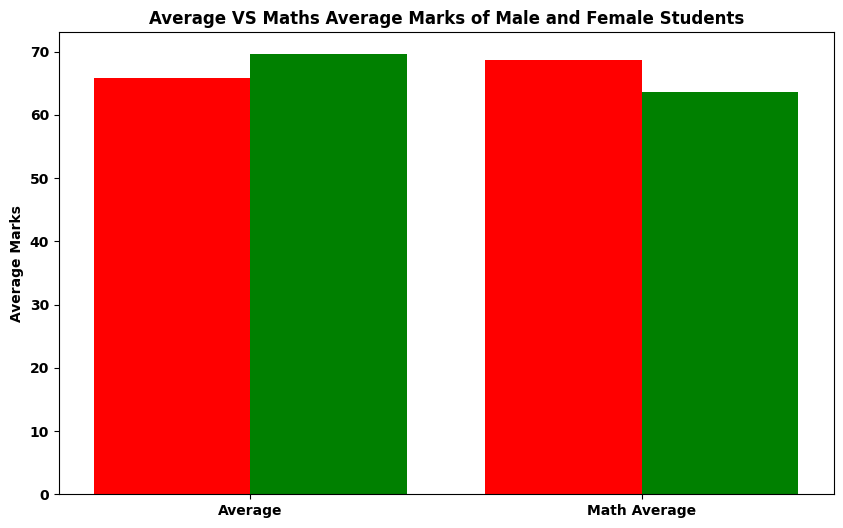

In [122]:
plt.figure(figsize=(10,6))

X = ['Average','Math Average']

female_score = [gender_group['Average'][0],gender_group['math score'][0]]
male_score = [gender_group['Average'][1],gender_group['math score'][1]]

X_axis = np.arange(len(X))
plt.xticks(X_axis,X,fontweight='bold')
plt.ylabel('Average Marks',fontweight='bold')
plt.setp(plt.gca().get_yticklabels(), fontweight='bold')
plt.title("Average VS Maths Average Marks of Male and Female Students",fontweight='bold')
plt.bar(X_axis - 0.2,male_score,0.4,label='Male',color='r')
plt.bar(X_axis + 0.2,female_score,0.4,label='Female',color='g')


In [123]:
femal_scores,male_score

([69.56949806949807, 63.633204633204635],
 [65.8374827109267, 68.72821576763485])

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

In [124]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

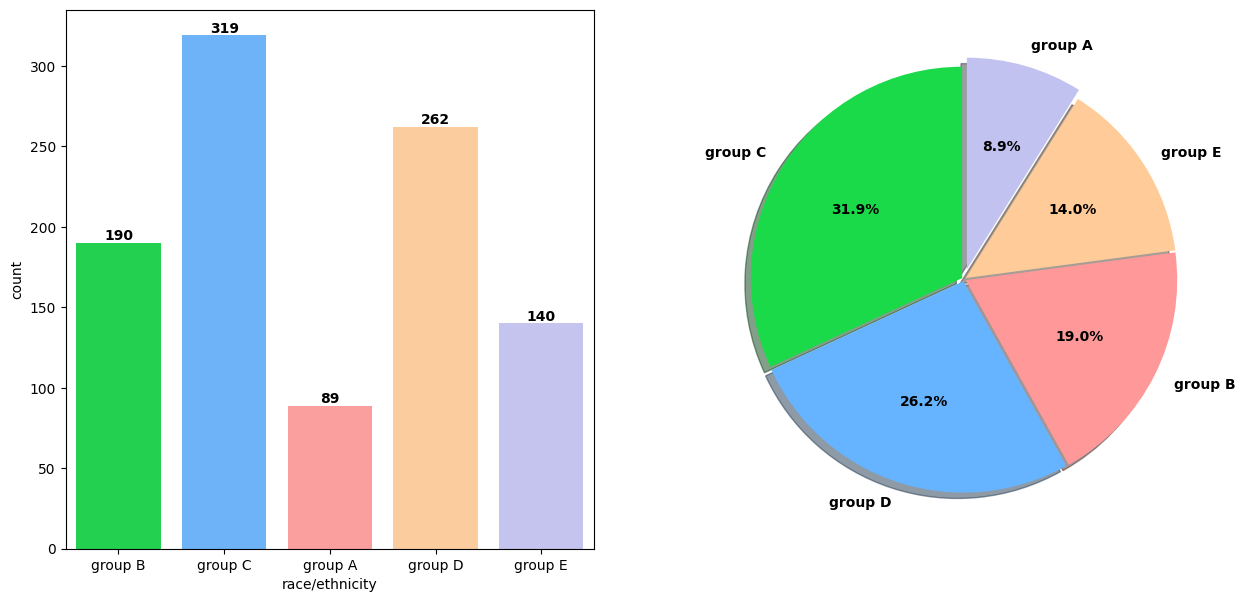

In [125]:
fig,axs = plt.subplots(1,2,figsize=(15,7))

sns.countplot(data=df,
              x='race/ethnicity',
              ax=axs[0],
              saturation=0.9,
              palette=["#1ada4a",'#66b3ff', '#ff9999', '#ffcc99', '#c2c2f0'])
for container in axs[0].containers:
    axs[0].bar_label(container,weight='bold')


axs[1].pie(df['race/ethnicity'].value_counts(),
           labels=df['race/ethnicity'].value_counts().index,
           autopct='%1.1f%%',
           startangle=90,
           colors=["#1ada4a",'#66b3ff', '#ff9999', '#ffcc99', '#c2c2f0'],
           explode=[0.01,0.01,0.01,0.01,0.05],
           shadow=True,
           textprops={'fontweight': 'bold'})
plt.show()

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

In [126]:
group_data2 = df.groupby('race/ethnicity').mean(numerical)
group_data2


,math score,reading score,writing score,Total Score,Average
race/ethnicity,,,,,
group A,61.629213,64.674157,62.674157,188.977528,62.992509
group B,63.452632,67.352632,65.600000,196.405263,65.468421
group C,64.463950,69.103448,67.827586,201.394984,67.131661
group D,67.362595,70.030534,70.145038,207.538168,69.179389
group E,73.821429,73.028571,71.407143,218.257143,72.752381


#### BIVARIATE ANALYSIS ( Is Race/Ethnicity has any impact on student's performance ? )

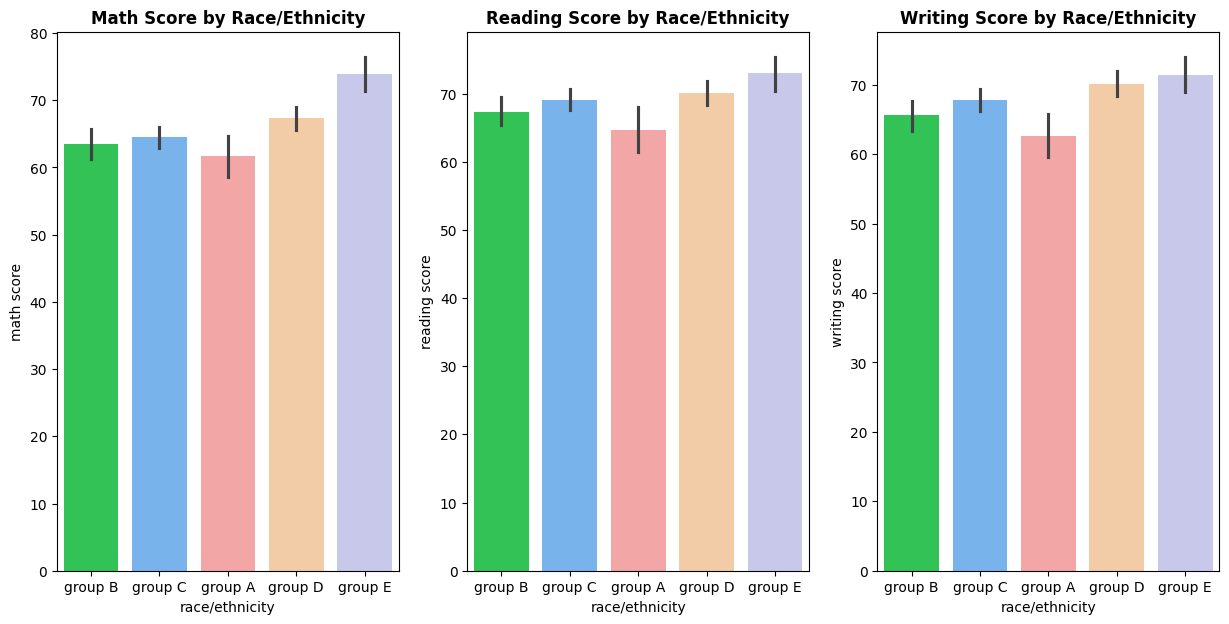

In [129]:

fig, axs = plt.subplots(1, 3, figsize=(15, 7))

sns.barplot(
    data=df,
    x='race/ethnicity',
    y='math score',
    ax=axs[0],
    palette=["#1ada4a", "#66b3ff", "#ff9999", "#ffcc99", "#c2c2f0"]
)
axs[0].set_title('Math Score by Race/Ethnicity', fontweight='bold')
sns.barplot(
    data=df,
    x='race/ethnicity',
    y='reading score',
    ax=axs[1],
    palette=["#1ada4a", "#66b3ff", "#ff9999", "#ffcc99", "#c2c2f0"]
)
axs[1].set_title('Reading Score by Race/Ethnicity', fontweight='bold')
sns.barplot(
    data=df,
    x='race/ethnicity',
    y='writing score',
    ax=axs[2],
    palette=["#1ada4a", "#66b3ff", "#ff9999", "#ffcc99", "#c2c2f0"]
)
axs[2].set_title('Writing Score by Race/Ethnicity', fontweight='bold')
plt.show()

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

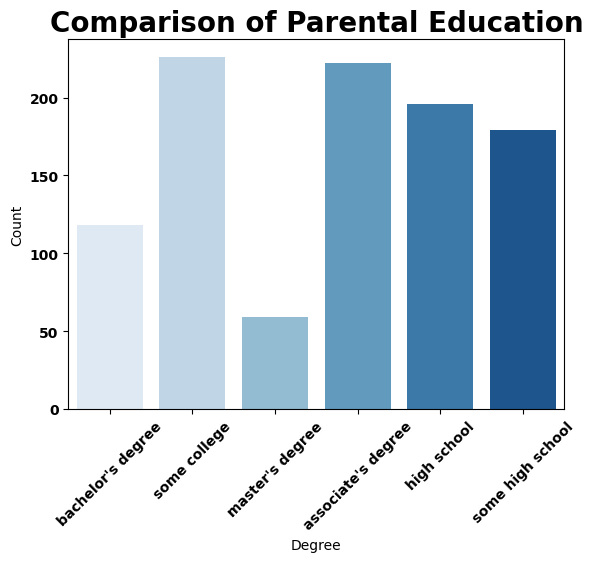

In [131]:
sns.countplot(
    data=df,
    x='parental_level_of_education',
    palette='Blues'
)

plt.title(
    'Comparison of Parental Education',
    fontweight='bold',
    fontsize=20
)

plt.xlabel('Degree')
plt.ylabel('Count')

plt.xticks(rotation=45, fontweight='bold')
plt.yticks(fontweight='bold')

plt.show()

#### Insights 
- Largest number of parents are from some college.

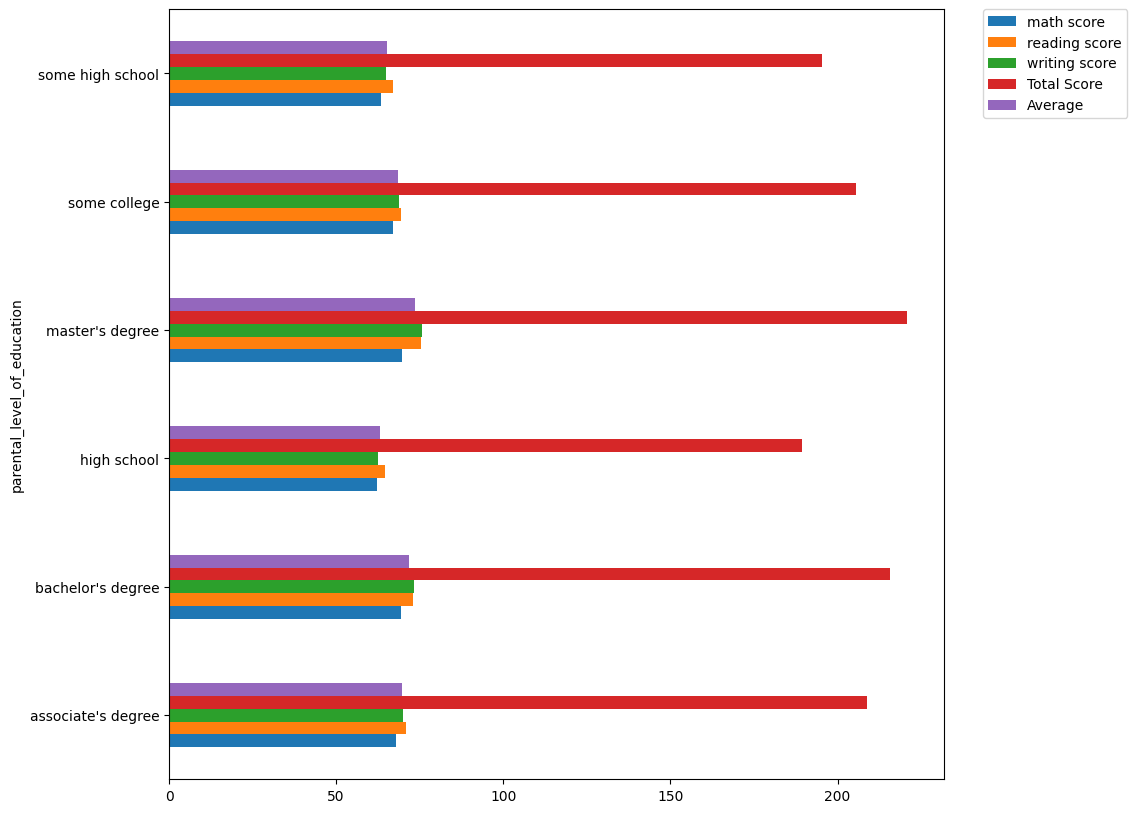

In [132]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='barh', figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

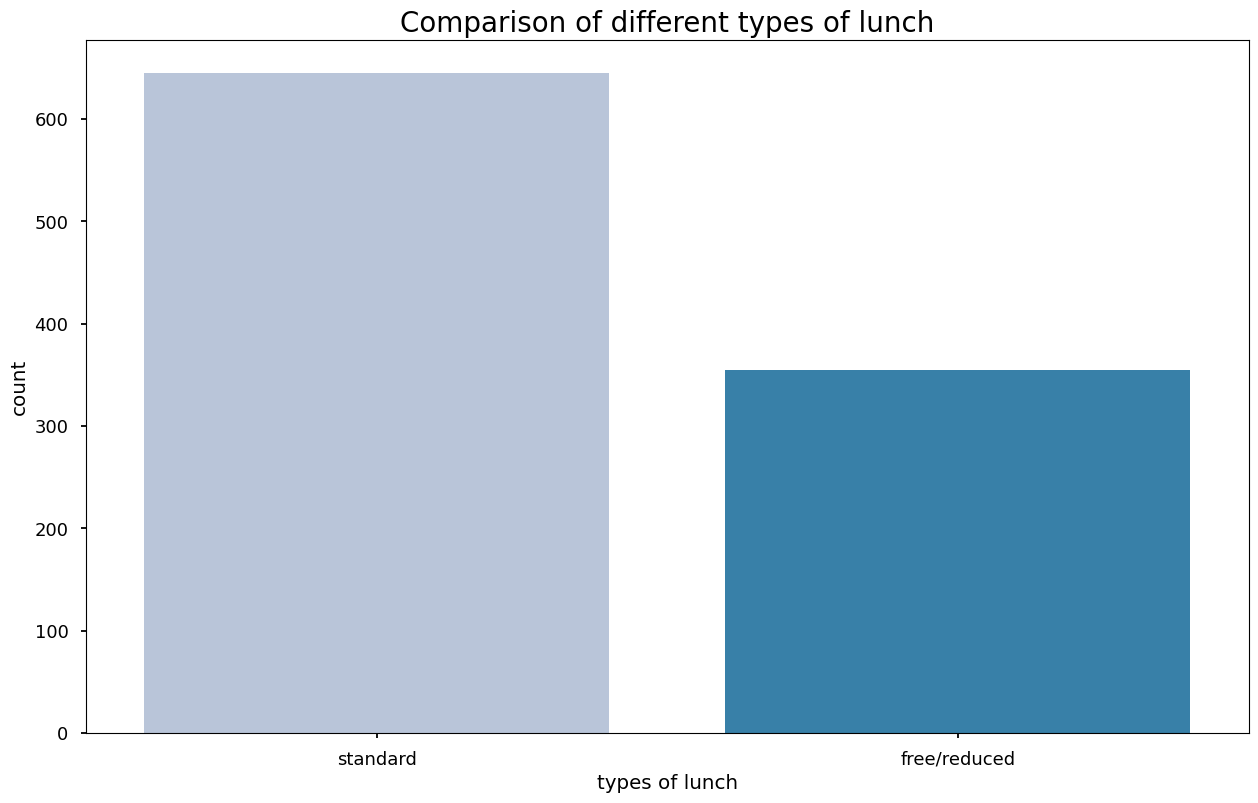

In [133]:
plt.style.use('seaborn-v0_8-talk')
plt.rcParams['figure.figsize'] = (15, 9)
sns.countplot(data=df, x='lunch', palette='PuBu')
plt.title('Comparison of different types of lunch', fontweight=30, fontsize=20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

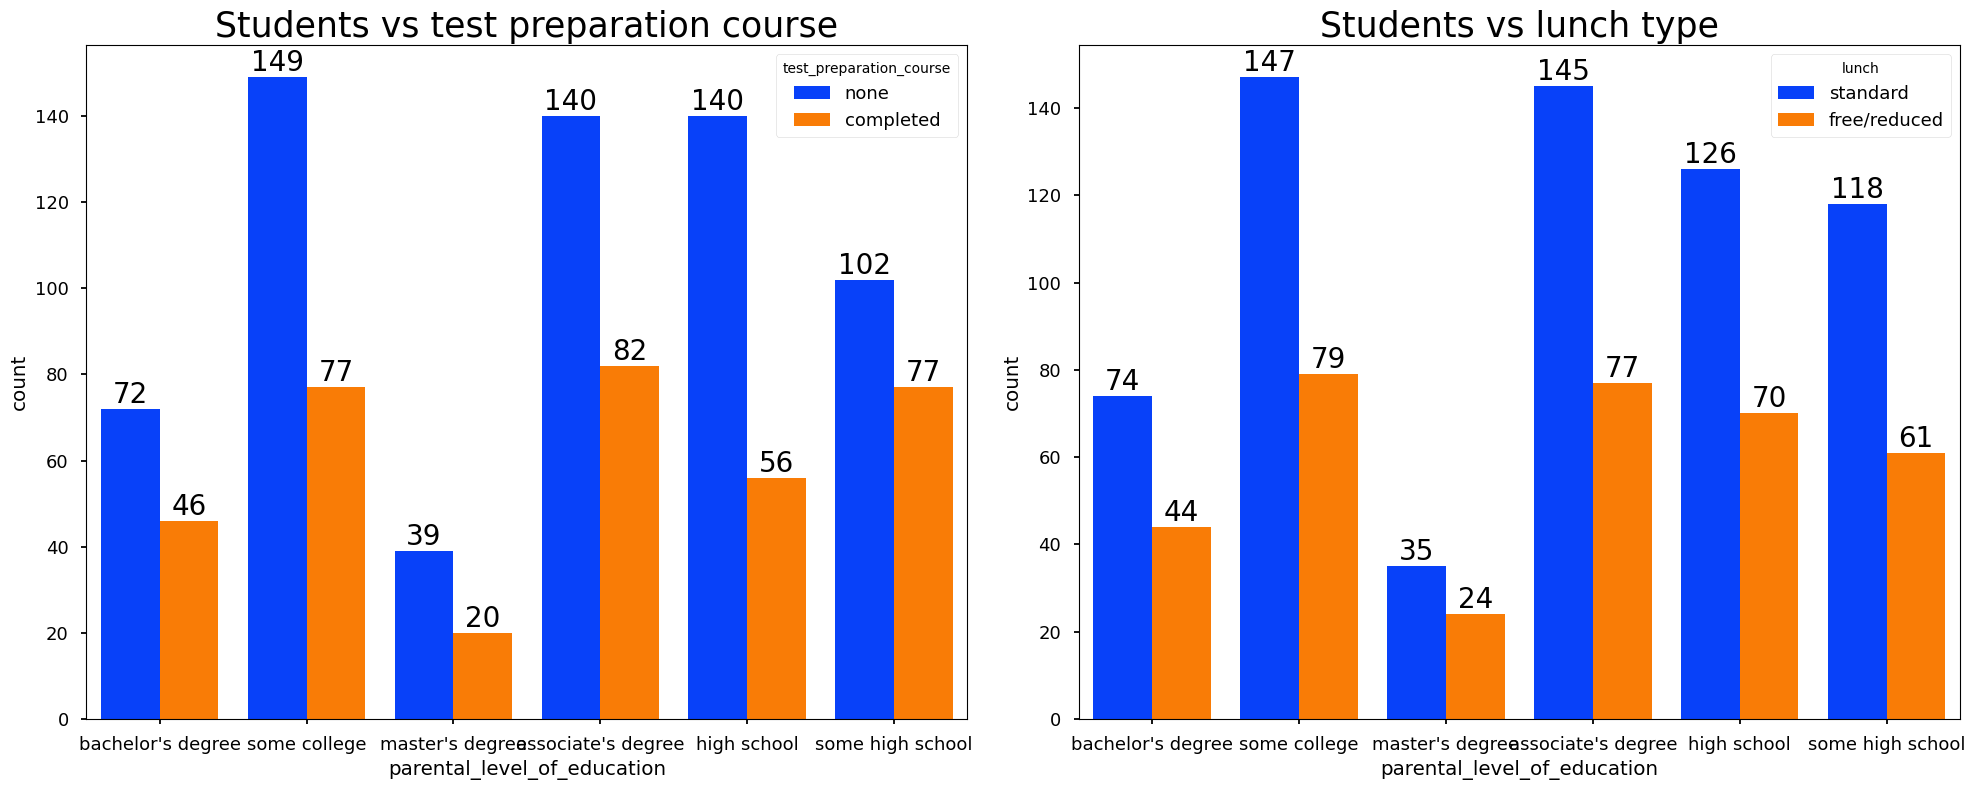

In [134]:
f, ax = plt.subplots(1, 2, figsize=(20,8))

sns.countplot(x='parental_level_of_education', data=df, palette='bright', hue='test_preparation_course', saturation=0.95, ax=ax[0])
ax[0].set_title('Students vs test preparation course', color='black', size=25)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

sns.countplot(x='parental_level_of_education', data=df, palette='bright', hue='lunch', saturation=0.95, ax=ax[1])
ax[1].set_title('Students vs lunch type', color='black', size=25)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)

plt.tight_layout()
plt.show()

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

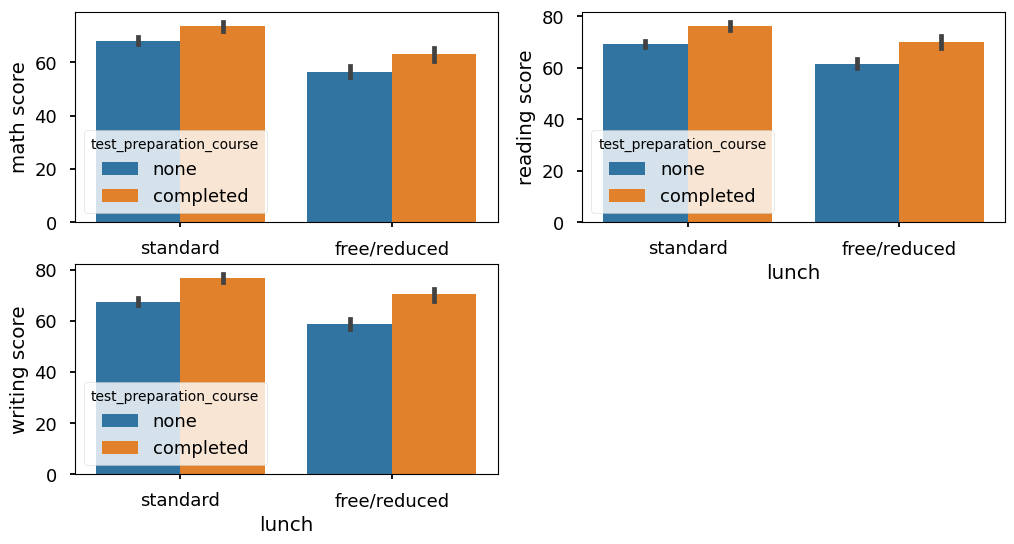

In [135]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test_preparation_course'])
plt.show()

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

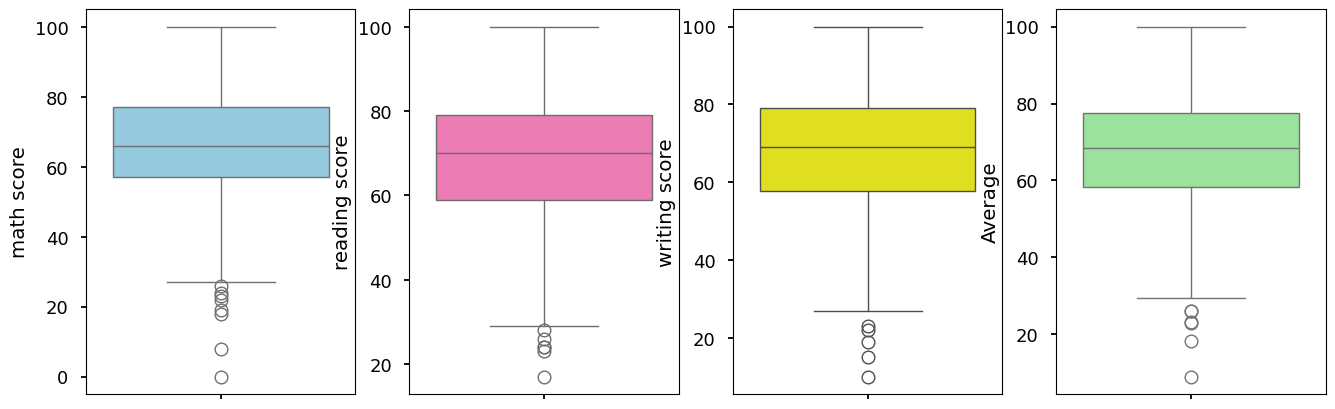

In [137]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['Average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

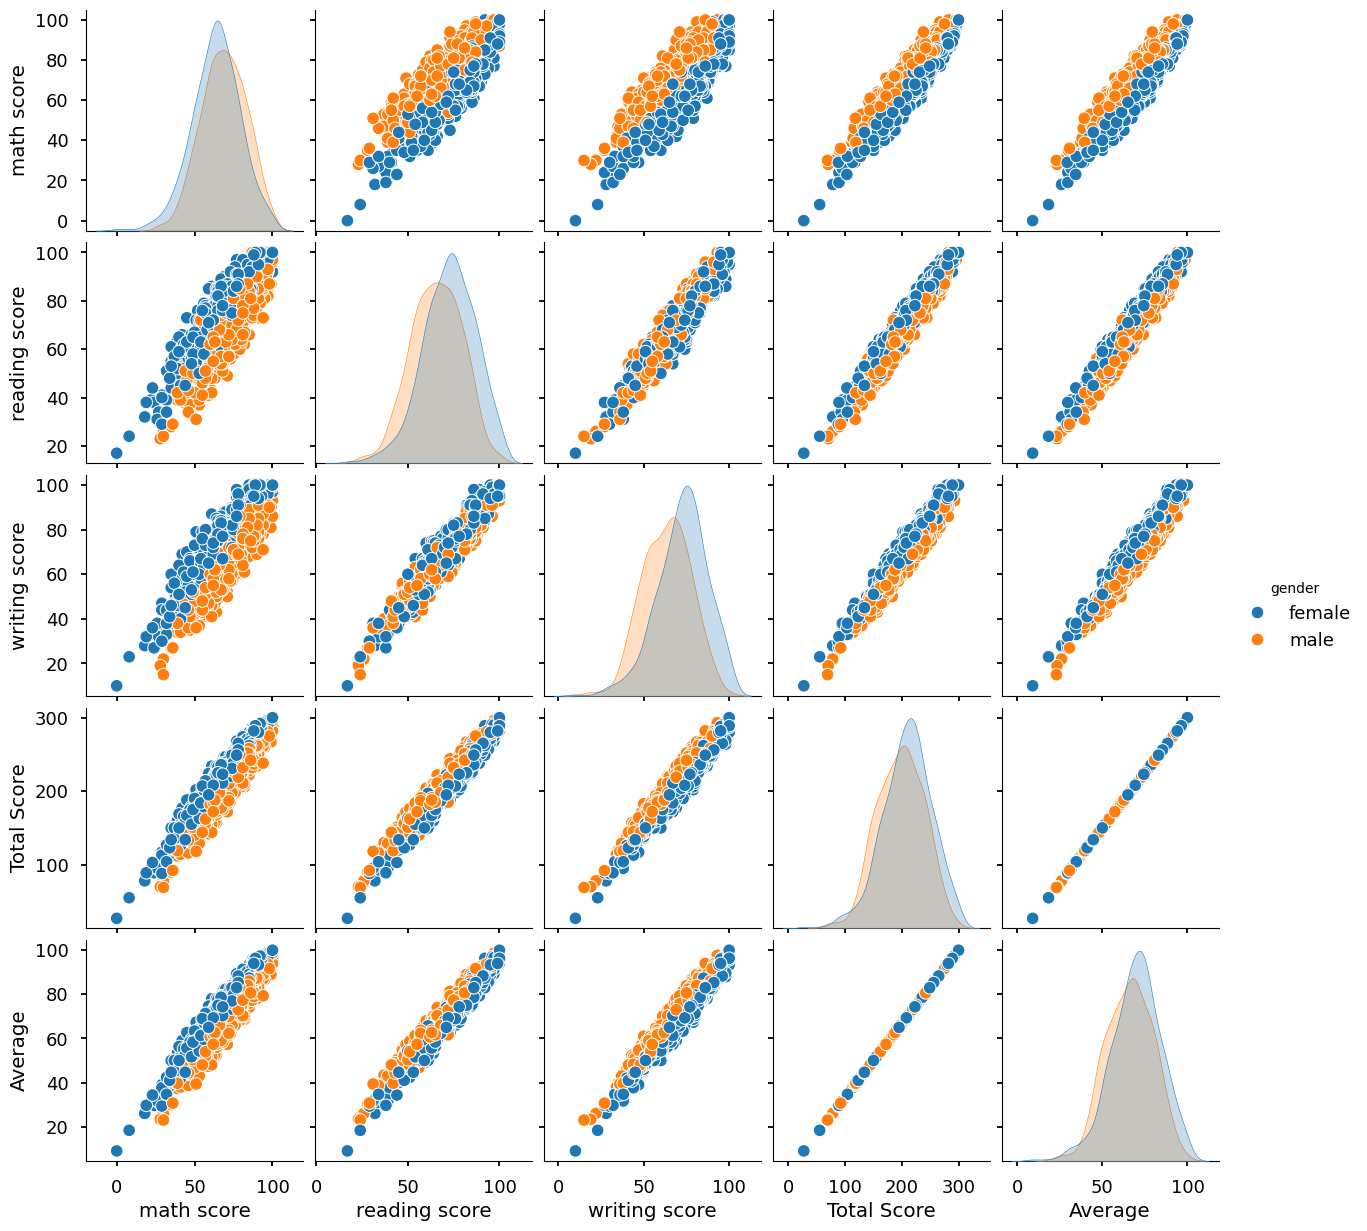

In [138]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.